In [ ]:
algorithm_name = 'ppo'

In [ ]:
# KNN
import pandas as pd
import numpy as np
import os
import joblib
from google.colab import drive
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder


#file paths
drive.mount('/content/drive', force_remount=True)
PROJECT_PATH = '/content/drive/MyDrive/RL_Predictor_Project'
PROCESSED_PATH = os.path.join(PROJECT_PATH, '02_Data_Processed')
MODEL_PATH = os.path.join(PROJECT_PATH, '04_Models')
VISUAL_PATH = os.path.join(PROJECT_PATH, '05_Visuals')

#Load data
df = pd.read_csv(os.path.join(PROCESSED_PATH, "master_data_alternative.csv"))
target = 'peak_ram_mb'
df[target] = pd.to_numeric(
    df[target], errors='coerce'
)
df = df.dropna(subset=[target])
df = df.sample(frac = 1).reset_index(drop=True)
df = df[df[target].notna()].copy()
df = df[df['algorithm']==algorithm_name].copy()

#Data
drop_cols = ['gpu', 'peak_ram_mb', 'timestamp','final_mean_reward','gpu_memory_gb','training_duration_seconds']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
#Target
y = df[target]

print(X)
print(y)

#Preprocessing data
# Automatically encode all text columns to numbers
encoders = {}
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        encoders[col] = le

# Fill any missing values with 0 so the model doesn't crash
X = X.fillna(0)
y = y.fillna(0)

#Kfold split
ksplit = KFold(n_splits = 10 , shuffle=True, random_state=42)
#Model
model = KNeighborsRegressor()

r2score = []
mae = []

for train_idx , val_idx in ksplit.split(X):
  X_train , X_val = X.iloc[train_idx] , X.iloc[val_idx]
  Y_train , Y_val = y.iloc[train_idx] , y.iloc[val_idx]

  model.fit(X_train,Y_train)
  pred = model.predict(X_val)

  r2score.append(r2_score(Y_val , pred))
  mae.append(mean_absolute_error(Y_val , pred))

mean_r2_score = np.mean(r2score)
mean_mae = np.mean(mae)
model.fit(X,y)
print(f"Mean r2 score: {mean_r2_score}")
print(f"Mean absolute error: {mean_mae}")
joblib.dump(model, os.path.join(MODEL_PATH, "ram_model_knn_"+algorithm_name+".pkl"))



Mounted at /content/drive
        enviroment algorithm  learning_rate  batch_size  hidden_units  \
0           3DBall       ppo       0.000099        2048            32   
1           3DBall       ppo       0.000123        4096            64   
2       3DBallHard       ppo       0.000217        4096            32   
3           3DBall       ppo       0.000116        4096           128   
4          Hallway       ppo       0.000231        4096            32   
...            ...       ...            ...         ...           ...   
356579      3DBall       ppo       0.000090        4096            32   
356580     Crawler       ppo       0.000283         512           256   
356581  3DBallHard       ppo       0.000068         512            32   
356582  3DBallHard       ppo       0.000275        2048           128   
356583      3DBall       ppo       0.000266         512           512   

        num_layers    steps     ram_gb  cpu_cores  time_horizon  buffer_size  \
0                

['/content/drive/MyDrive/RL_Predictor_Project/04_Models/ram_model_knn_ppo.pkl']

In [ ]:
# Artificial Neural networks
import pandas as pd
import numpy as np
import os
import joblib
from google.colab import drive
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor


#file paths
drive.mount('/content/drive', force_remount=True)
PROJECT_PATH = '/content/drive/MyDrive/RL_Predictor_Project'
PROCESSED_PATH = os.path.join(PROJECT_PATH, '02_Data_Processed')
MODEL_PATH = os.path.join(PROJECT_PATH, '04_Models')
VISUAL_PATH = os.path.join(PROJECT_PATH, '05_Visuals')

#Load data
df = pd.read_csv(os.path.join(PROCESSED_PATH, "master_data_alternative.csv"))
target = 'peak_ram_mb'
df[target] = pd.to_numeric(
    df[target], errors='coerce'
)
df = df.dropna(subset=[target])
df = df.sample(frac = 1).reset_index(drop=True)
df = df[df[target].notna()].copy()
df = df[df['algorithm']==algorithm_name].copy()

#Data
drop_cols = ['gpu', 'peak_ram_mb', 'timestamp','final_mean_reward','gpu_memory_gb','training_duration_seconds']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
#Target
y = df[target]


#Preprocessing data
# Automatically encode all text columns to numbers
encoders = {}
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        encoders[col] = le

# Fill any missing values with 0 so the model doesn't crash
X = X.fillna(0)

#Kfold split
ksplit = KFold(n_splits = 10 , shuffle=True, random_state=42)
#Model

mlp = MLPRegressor(max_iter=1000)

r2score = []
mae = []

for train_idx , val_idx in ksplit.split(X):
  X_train , X_val = X.iloc[train_idx] , X.iloc[val_idx]
  Y_train , Y_val = y.iloc[train_idx] , y.iloc[val_idx]

  mlp.fit(X_train,Y_train)
  pred = mlp.predict(X_val)

  r2score.append(r2_score(Y_val , pred))
  mae.append(mean_absolute_error(Y_val , pred))

  mean_r2_score = np.mean(r2score)
  mean_mae = np.mean(mae)

mlp.fit(X,y)
print("-"*20)
print(f"Mean r2 score: {mean_r2_score}")
print(f"Mean absolute error: {mean_mae}")
joblib.dump(mlp, os.path.join(MODEL_PATH, "ram_model_ann_"+algorithm_name+".pkl"))
print(f"Model saved at {MODEL_PATH}")


Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


KeyboardInterrupt: 

In [ ]:
# Regression Forest Tree
import pandas as pd
import numpy as np
import os
import joblib
from google.colab import drive
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

#file paths
drive.mount('/content/drive', force_remount=True)
PROJECT_PATH = '/content/drive/MyDrive/RL_Predictor_Project'
PROCESSED_PATH = os.path.join(PROJECT_PATH, '02_Data_Processed')
MODEL_PATH = os.path.join(PROJECT_PATH, '04_Models')
VISUAL_PATH = os.path.join(PROJECT_PATH, '05_Visuals')

#Load data
df = pd.read_csv(os.path.join(PROCESSED_PATH, "master_data_alternative.csv"))
target = 'peak_ram_mb'
df[target] = pd.to_numeric(
    df[target], errors='coerce'
)
df = df.dropna(subset=[target])
df = df.sample(frac = 1).reset_index(drop=True)
df = df[df[target].notna()].copy()
df = df[df['algorithm']==algorithm_name].copy()

#Data
drop_cols = ['gpu', 'peak_ram_mb', 'timestamp','final_mean_reward','gpu_memory_gb','training_duration_seconds']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
#Target
y = df[target]

#Removing sac algo

#Preprocessing data
# Automatically encode all text columns to numbers
encoders = {}
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        encoders[col] = le

# Fill any missing values with 0 so the model doesn't crash
X = X.fillna(0)

#Kfold split
ksplit = KFold(n_splits = 10 , shuffle=True, random_state=42)
#Model
rfr = RandomForestRegressor(n_estimators=100 , min_samples_leaf=4,min_samples_split=5)

r2score = []
mae = []

for train_idx , val_idx in ksplit.split(X):
  X_train , X_val = X.iloc[train_idx] , X.iloc[val_idx]
  Y_train , Y_val = y.iloc[train_idx] , y.iloc[val_idx]

  rfr.fit(X_train,Y_train)
  pred = rfr.predict(X_val)

  r2score.append(r2_score(Y_val , pred))
  mae.append(mean_absolute_error(Y_val , pred))

rfr.fit(X,y)
mean_r2_score = np.mean(r2score)
mean_mae = np.mean(mae)
print("-"*20)
print(f"Mean r2 score: {mean_r2_score}")
print(f"Mean absolute error: {mean_mae}")
joblib.dump(rfr, os.path.join(MODEL_PATH, "ram_model_rfr_"+algorithm_name+".pkl"))
print(f"Model saved at {MODEL_PATH}")



Mounted at /content/drive
--------------------
Mean r2 score: 0.9556305866761752
Mean absolute error: 621.7229490204697
Model saved at /content/drive/MyDrive/RL_Predictor_Project/04_Models


In [ ]:
# Linear Regression
import pandas as pd
import numpy as np
import os
import joblib
from google.colab import drive
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


#file paths
drive.mount('/content/drive', force_remount=True)
PROJECT_PATH = '/content/drive/MyDrive/RL_Predictor_Project'
PROCESSED_PATH = os.path.join(PROJECT_PATH, '02_Data_Processed')
MODEL_PATH = os.path.join(PROJECT_PATH, '04_Models')
VISUAL_PATH = os.path.join(PROJECT_PATH, '05_Visuals')

#Load data
df = pd.read_csv(os.path.join(PROCESSED_PATH, "master_data_alternative.csv"))
target = 'peak_ram_mb'
df[target] = pd.to_numeric(
    df[target], errors='coerce'
)
df = df.dropna(subset=[target])
df = df.sample(frac = 1).reset_index(drop=True)
df = df[df[target].notna()].copy()
df = df[df['algorithm']==algorithm_name].copy()

#Data
drop_cols = ['gpu', 'peak_ram_mb', 'timestamp','final_mean_reward','gpu_memory_gb','training_duration_seconds']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
#Target
y = df[target]

#Preprocessing data
# Automatically encode all text columns to numbers
encoders = {}
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        encoders[col] = le

# Fill any missing values with 0 so the model doesn't crash
X = X.fillna(0)

#Kfold split
ksplit = KFold(n_splits = 10 , shuffle=True, random_state=42)
#Model
lr = LinearRegression()

r2score = []
mae = []

for train_idx , val_idx in ksplit.split(X):
  X_train , X_val = X.iloc[train_idx] , X.iloc[val_idx]
  Y_train , Y_val = y.iloc[train_idx] , y.iloc[val_idx]

  lr.fit(X_train,Y_train)
  pred = lr.predict(X_val)

  r2score.append(r2_score(Y_val , pred))
  mae.append(mean_absolute_error(Y_val , pred))

lr.fit(X,y)
mean_r2_score = np.mean(r2score)
mean_mae = np.mean(mae)

print(f"Mean r2 score: {mean_r2_score}")
print(f"Mean absolute error: {mean_mae}")
joblib.dump(lr, os.path.join(MODEL_PATH, "ram_model_lr_"+algorithm_name+".pkl"))
print(f"Model saved at {MODEL_PATH}")

Mounted at /content/drive
Mean r2 score: 0.8610358324102029
Mean absolute error: 1795.8917645249871
Model saved at /content/drive/MyDrive/RL_Predictor_Project/04_Models


In [ ]:
# Extra trees Regressor
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import joblib
from google.colab import drive
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import ExtraTreesRegressor

#file paths
drive.mount('/content/drive', force_remount=True)
PROJECT_PATH = '/content/drive/MyDrive/RL_Predictor_Project'
PROCESSED_PATH = os.path.join(PROJECT_PATH, '02_Data_Processed')
MODEL_PATH = os.path.join(PROJECT_PATH, '04_Models')
VISUAL_PATH = os.path.join(PROJECT_PATH, '05_Visuals')

#Load data
df = pd.read_csv(os.path.join(PROCESSED_PATH, "master_data_alternative.csv"))
target = 'peak_ram_mb'
df[target] = pd.to_numeric(
    df[target], errors='coerce'
)
df = df.dropna(subset=[target])
df = df.sample(frac = 1).reset_index(drop=True)
df = df[df[target].notna()].copy()
df = df[df['algorithm']==algorithm_name].copy()

#Data
drop_cols = ['gpu', 'peak_ram_mb', 'timestamp','final_mean_reward','gpu_memory_gb','training_duration_seconds']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
#Target
y = df[target]

#Preprocessing data
# Automatically encode all text columns to numbers
encoders = {}
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        encoders[col] = le

# Fill any missing values with 0 so the model doesn't crash
X = X.fillna(0)
print()
#Kfold split
ksplit = KFold(n_splits = 10 , shuffle=True, random_state=42)

#Model

etr = ExtraTreesRegressor(n_estimators=100 , min_samples_leaf=4,min_samples_split=5,bootstrap=False)

r2score = []
mae = []

for train_idx , val_idx in ksplit.split(X):
  X_train , X_val = X.iloc[train_idx] , X.iloc[val_idx]
  Y_train , Y_val = y.iloc[train_idx] , y.iloc[val_idx]

  etr.fit(X_train,Y_train)
  pred = etr.predict(X_val)

  r2score.append(r2_score(Y_val , pred))
  mae.append(mean_absolute_error(Y_val , pred))

mean_r2_score = np.mean(r2score)
mean_mae = np.mean(mae)

etr.fit(X,y)
print("-"*20)
#print(f"i value: {i}")
print(f"Mean r2 score: {mean_r2_score}")
print(f"Mean absolute error: {mean_mae}")
joblib.dump(etr, os.path.join(MODEL_PATH, "ram_model_etr_"+algorithm_name+".pkl"))
print(f"Model saved at {MODEL_PATH}")


Mounted at /content/drive
--------------------
Mean r2 score: 0.955575705416645
Mean absolute error: 619.887839035329
Model saved at /content/drive/MyDrive/RL_Predictor_Project/04_Models


In [ ]:
#HistBoostingRegressor
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor



# 1. MOUNT AND PATHS
drive.mount('/content/drive', force_remount=True)
PROJECT_PATH = '/content/drive/MyDrive/RL_Predictor_Project'
PROCESSED_PATH = os.path.join(PROJECT_PATH, '02_Data_Processed')
MODEL_PATH = os.path.join(PROJECT_PATH, '04_Models')
VISUAL_PATH = os.path.join(PROJECT_PATH, '05_Visuals')

# 2. LOAD DATA
df = pd.read_csv(os.path.join(PROCESSED_PATH, "master_data_alternative.csv"))
target = 'peak_ram_mb'
df[target] = pd.to_numeric(
    df[target], errors='coerce'
)
df = df.dropna(subset=[target])
df = df.sample(frac = 1).reset_index(drop=True)
df = df[df[target].notna()].copy()
df = df[df['algorithm']==algorithm_name].copy()

#Data
drop_cols = ['gpu', 'peak_ram_mb', 'timestamp','final_mean_reward','gpu_memory_gb','training_duration_seconds']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
#Target
y = df[target]

# Fill any missing values with 0 so the model doesn't crash
X = X.fillna(0)

# Automatically encode all text columns to numbers
encoders = {}
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        encoders[col] = le

model = HistGradientBoostingRegressor(
    learning_rate=0.1,
    min_samples_leaf=3,
    l2_regularization=0.1,
    random_state=42,
    max_bins=180,
    early_stopping=True)

# 4. K-FOLD CROSS VALIDATION

kf = KFold(n_splits=10, shuffle=True, random_state=42)

mae_scores = []
r2_scores = []

print(f"🚀 Training HistogramGradientBoostingRegressor on {len(df)} rows...")

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds_real = pd.DataFrame(preds)
    # print("-"*20)
    # print("preds_real:")
    # print(preds_real)

    y_test_real = y_test
    # print("-"*20)
    # print("y_test_real:")
    # print(y_test_real)

    mae_scores.append(mean_absolute_error(y_test_real, preds_real))
    r2_scores.append(r2_score(y_test_real, preds_real))

# 5. RESULTS & SAVING
avg_mae = np.mean(mae_scores)
avg_r2 = np.mean(r2_scores)

model.fit(X, y)

print("\n" + "="*30)
print(f"FINAL MAE: {avg_mae:.2f} ± {np.std(mae_scores):.2f}")
print(f"FINAL R2:  {avg_r2:.4f} ± {np.std(r2_scores):.2f}")
print("="*30)

# Save Model
# Refit model on ALL data before saving

os.makedirs(MODEL_PATH, exist_ok=True)
joblib.dump(model, os.path.join(MODEL_PATH, "ram_model_hgbr_"+algorithm_name+".pkl"))
print(f"Model saved to {MODEL_PATH}")

Mounted at /content/drive
🚀 Training HistogramGradientBoostingRegressor on 5407 rows...

FINAL MAE: 618.63 ± 49.29
FINAL R2:  0.9558 ± 0.01
Model saved to /content/drive/MyDrive/RL_Predictor_Project/04_Models


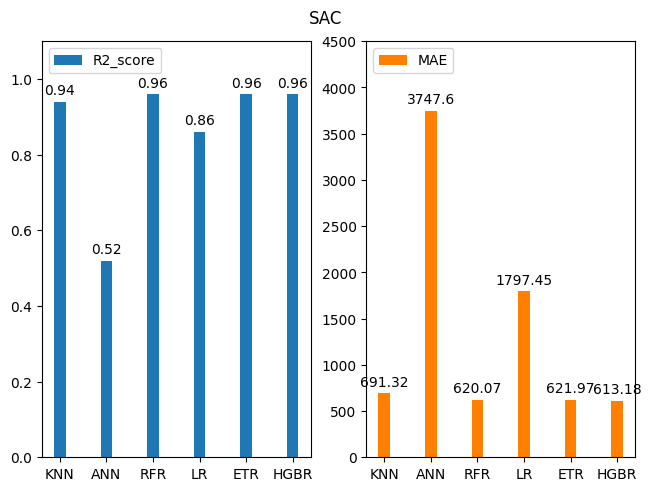

In [ ]:
#Results and charts for SAC
import matplotlib.pyplot as plt
import numpy as np

#First MAE 2nd R2
Results_KNN = [633.39 , 0.94]
Results_ANN = [3747.60 , 0.52]
Results_RFR = [620.07, 0.96]
Results_LR = [1797.45 , 0.86]
Results_ETR = [621.97 , 0.96]
Results_HGBR = [613.18 , 0.96]

models = ('KNN','ANN','RFR','LR','ETR' , 'HGBR')
MAE_R2 = {'R2_score':(0.94,0.52,0.96,0.86,0.96,0.96),
          'MAE':np.array([691.32,3747.60,620.07,1797.45,621.97,613.18])
}

x = np.arange(len(models))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(ncols=2,nrows=1,layout='constrained')

items = MAE_R2.items()

attribute1, measurement1 = 'R2_score',tuple(MAE_R2['R2_score'])
attribute2, measurement2 = 'MAE',tuple(MAE_R2['MAE'])

offset = width * multiplier
rects = ax[0].bar(x + offset, measurement1, width, label=attribute1)
ax[0].bar_label(rects, padding=3)
ax[0].set_ylim(0, 1.1)
ax[0].set_xticks(x, models)
ax[0].legend(loc='upper left', ncols=3)

offset = width * multiplier
rects = ax[1].bar(x + offset, measurement2, width, label=attribute2,color=(1.0,0.5,0.0))
ax[1].bar_label(rects, padding=3)
ax[1].set_ylim(0, 4500)
ax[1].set_xticks(x, models)
ax[1].legend(loc='upper left', ncols=3)

fig.suptitle("SAC")

plt.show()

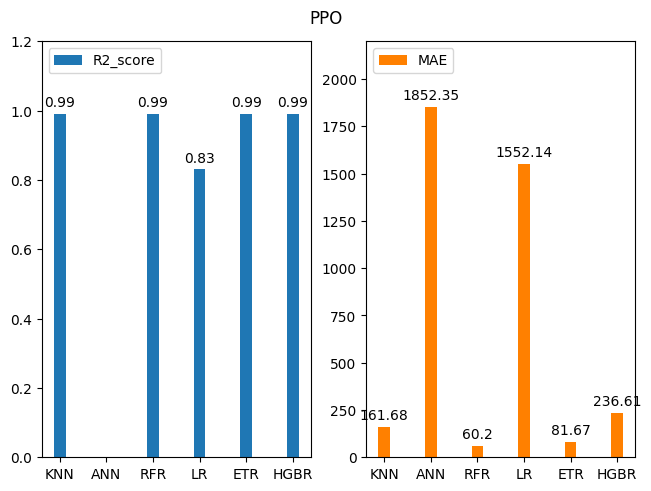

In [ ]:
#Results and charts for PPO
import matplotlib.pyplot as plt
import numpy as np

#First MAE 2nd R2
Results_KNN = [57.54 , 0.99]
Results_ANN = [1852.35 , -8.82]
Results_RFR = [60.20, 0.99]
Results_LR = [1552.14 , 0.83]
Results_ETR = [81.67, 0.99]
Results_HGBR = [236.61, 0.99]


models = ('KNN','ANN','RFR','LR','ETR' , 'HGBR')
MAE_R2 = {'R2_score':(0.99,-8.82,0.99,0.83,0.99,0.99),
          'MAE':np.array([161.68,1852.35,60.20,1552.14,81.67,236.61])
}

x = np.arange(len(models))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(ncols=2,nrows=1,layout='constrained')

items = MAE_R2.items()

attribute1, measurement1 = 'R2_score',tuple(MAE_R2['R2_score'])
attribute2, measurement2 = 'MAE',tuple(MAE_R2['MAE'])

offset = width * multiplier
rects = ax[0].bar(x + offset, measurement1, width, label=attribute1)
ax[0].bar_label(rects, padding=3)
ax[0].set_ylim(0, 1.2)
ax[0].set_xticks(x, models)
ax[0].legend(loc='upper left', ncols=3)

offset = width * multiplier
rects = ax[1].bar(x + offset, measurement2, width, label=attribute2,color=(1.0,0.5,0.0))
ax[1].bar_label(rects, padding=3)
ax[1].set_ylim(0, 2200)
ax[1].set_xticks(x, models)
ax[1].legend(loc='upper left', ncols=3)

fig.suptitle("PPO")

plt.show()

Experiments
This section will be explaining how we conducted the experiment for the second research question , regarding predicting the performance of an ml agent. The metric which we used to determine perfrormance is final mean reward. In order to conduct the experiment we used a method divided in several stages and replicated mutliple times to see the reults.

First of all , we loaded the data from the master.csv file and preprocessed the data. In this stage we removed all the rows that contain empty cells of our target metric , as well as excluding the columns: peak_ram_mb and time_duration_sec , as these hyperparameters directly correlate to final mean reward,due to the fact that as they grow , the performance becomes better.
After preocessing we split the dataset into training and testing using KFold cross validation tehnique , where the amount of folds is 10.
Now that all the data is ready to be used , we applied different model predictors in order to diverse our reults and reach conclusions about our data.The models that we chose are:knn regressor , linear regression , mlp regressor , random forest regressor , extra tree regressor and hist gradient boosting regressor. To see which models performed the best we used r2 score and mean absolute error , as we are predicting a continious value. The experiment was conducted for two separate algoritms: ppo and sac. PPO has much more data than SAC , however the results proved to have the same pattern.As we discuss interpretation of experiments we will be referring to both algorithms.

Interpertation of results
Linear regression is not optimal for our data , as it proves our data does not interract linearly.

Artificial Neural Networks(MLP Regressor) can be a good model if not for our resource constraints , as far as we optimized it gave us the same results as linear regression. As we concluded , after testing there was no point in pursuing it , as it would time consuming.

RandomForestRegressor and ExtraTrees is one of best models in terms of results. Their robust nature and randomness are good features for nonlinear data and its interactions.

HistGradientRegressor proves to be a good model for our data , but it scales poorly. The more data we have , the mean abosulute error grows. There is a good argument for further optimization of the model , but due to time constraints this was the best it came up with.

KNN Regressor firstly gave similar results as linear regression , but as the data grew knn proved to be our best model. The huge amount of data helped knn scale incredibly well.



In [ ]:
# Display a graph of the game frequencies in data

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os



# 1. MOUNT AND PATHS
drive.mount('/content/drive', force_remount=True)
PROJECT_PATH = '/content/drive/MyDrive/RL_Predictor_Project'
PROCESSED_PATH = os.path.join(PROJECT_PATH, '02_Data_Processed')
MODEL_PATH = os.path.join(PROJECT_PATH, '04_Models')
VISUAL_PATH = os.path.join(PROJECT_PATH, '05_Visuals')


Mounted at /content/drive
Mounted at /content/drive


[Text(0, 0, '163755'),
 Text(0, 0, '125143'),
 Text(0, 0, '16'),
 Text(0, 0, '2'),
 Text(0, 0, '26776'),
 Text(0, 0, '4'),
 Text(0, 0, '20835'),
 Text(0, 0, '763'),
 Text(0, 0, '7246'),
 Text(0, 0, '11074'),
 Text(0, 0, '1273'),
 Text(0, 0, '1929'),
 Text(0, 0, '1977'),
 Text(0, 0, '1913')]

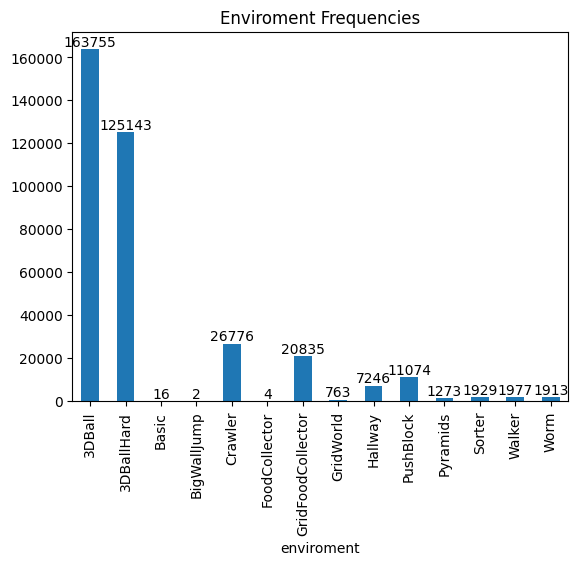

In [ ]:
# 2. LOAD DATA
import pandas as pd
df = pd.read_csv(os.path.join(PROCESSED_PATH, "master_data_alternative.csv"))

freq = df.groupby(['enviroment']).size()

ax = freq.plot.bar()

plt.title('Enviroment Frequencies')
ax.bar_label(ax.containers[0])

[Text(0, 0, '357139'), Text(0, 0, '5567')]

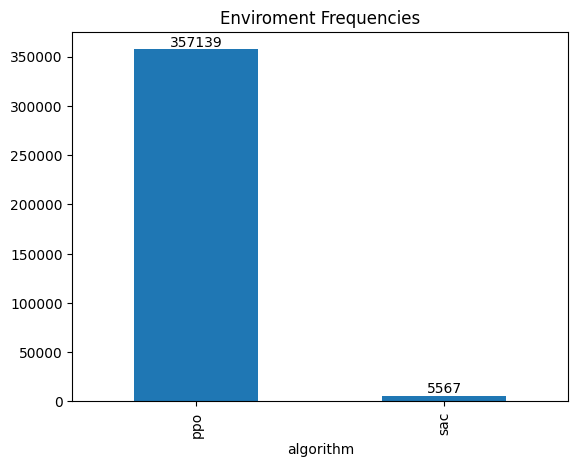

In [ ]:
freq = df.groupby(['algorithm']).size()

ax = freq.plot.bar()

plt.title('Enviroment Frequencies')
ax.bar_label(ax.containers[0])

# For Discussion
One of the issues we identified was a dominant frequency of the PPO algorithm usage in the training data [insert reference to a plot]. Due to this, we had to split the training data into two: PPO and SAC. It could have been possible to create a single model if we had sufficient data for SAC, but that wasn’t the case for us. Future improvement could be investing more time into training and making sure the algorithm frequency is not so skewed.

A similar issue occurred with the frequencies of the environments [insert reference to a plot]. Two issues can be observed: Dominant frequency of the 3DBall environment and insufficient frequency of couple environments, for example, “FoodCollector”. The solution to the problem can be similar to the algorithm frequency problem; make sure the frequency of the environments is not one-sided and is more balanced.